In [14]:
from utils import *
from genData import *
from model.unet import Attention_UNet
import time 
np.random.seed(111)
torch.manual_seed(111)

In [2]:
det = 'H1L1'
f0 = 20
size = (512, 64)
Tsft = 14400
max_train_levels = [40.2790268006]

filename = '/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{0}Hz_H1L1_{1}x{2}_{3}s_4c_traindata_n{4}_seed4.npz'.format(f0, size[0], size[1], Tsft, 1000)
targets = np.load(filename, allow_pickle=True)['clean_image']
masks = new_mask(normalize(targets))

data = []
mask_data = []
target_data = []
label_data = []
for Sn in max_train_levels:
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)

    data.append(normalize(noise + targets))
    mask_data.append(masks)
    target_data.append(normalize(targets))
    labels = [Sn] * noise.shape[0]  # Extend labels
    label_data.append(labels)
        
data = np.concatenate(data)
mask_data = np.concatenate(mask_data)
target_data = np.concatenate(target_data)
label_data = np.concatenate(label_data)
data = load_signal_datasetv2(data, target_data, mask_data, label_data)
    
noise = np.empty((1000,) + size + (4,))
for i in range(noise.shape[0]):
    noise[i] = simNoise(sqrtSn=1, Tsft=Tsft, size=size, ndet=2, norm=False)
noise = normalize(noise)
noise_data = load_noise_dataset(noise)
val_loader = make_data_loader([data, noise_data], batch_size=8, shuffle=False)

In [6]:
import matplotlib.pyplot as plt

model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)

if f0 == 20:
    train_level = 32

version = f'H1L1_a1.0b1.0_{f0}Hz_D{train_level}-{train_level}_T10_Tsft14400_ndata7000_noise7000_latent64_batch8_lr0.0001_512x64_MSELoss_dropout0'

best_val_model = torch.load(f"../trained_model/{f0}Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False)
#best_val_model = torch.load(f"./trained_model/{f0}Hz/{version}.pth", weights_only=False)
model.load_state_dict(best_val_model)

model.eval()  # Set model to evaluation mode
model.to(device)

inputs = [] 
predictions = []
ground_truth = []
masks = []
labels = []
stats = []

with torch.no_grad():  # No gradient computation needed during evaluation
    for test_batch in tqdm(val_loader):
        test_images, test_targets, test_masks, test_labels = test_batch

        # Move data to the specified device
        test_images = test_images.to(device)
        test_targets = test_targets.to(device)
        test_masks = test_masks.to(device)
        test_labels = test_labels.to(device)

        # Forward pass
        outputs = model(test_images)
        # Collect results
        inputs.append(test_images.cpu().numpy())
        predictions.append(outputs.cpu().numpy())
        ground_truth.append(test_targets.cpu().numpy())
        masks.append(test_masks.cpu().numpy())
        labels.append(test_labels.cpu().numpy())

inputs = np.concatenate(inputs, axis=0)
predictions = np.concatenate(predictions, axis=0)
ground_truth = np.concatenate(ground_truth, axis=0)
masks = np.concatenate(masks, axis=0)
labels = np.concatenate(labels, axis=0)

100%|██████████| 250/250 [00:13<00:00, 18.30it/s]


In [7]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Print the number of trainable parameters
print(f"Number of trainable parameters: {count_trainable_parameters(model)}")

Number of trainable parameters: 34879348


In [8]:
def compute_detection_statistic(images, method= 'mean'):
    """
    Compute detection statistic for each image using specified method.

    Args:
        images (torch.Tensor): Input images, shape (batch_size, C, H, W).
        method (str): Method to compute statistic. Options: 'mean', 'mean_sq', 
                     'kl_one', 'kl_random'. Defaults to 'mean'.

    Returns:
        np.ndarray: Detection statistics for each image, shape (batch_size,).

    Raises:
        ValueError: If method is invalid or input tensor has incorrect shape.
        TypeError: If input is not a torch.Tensor.
    """
    valid_methods = {'mean', 'mean_sq', 'kl_one', 'kl_random'}
    if method not in valid_methods:
        raise ValueError(f"Method must be one of {valid_methods}, got {method}")

    images_np = np.abs(images)
                          
    if method == 'mean':
        return np.mean(images_np.transpose(0, 2, 3, 1), axis=(1, 2, 3))
    
    elif method == 'mean_sq':
        return np.mean(np.square(images_np.transpose(0, 2, 3, 1)), axis=(1, 2, 3))
    
    elif method == 'kl_one':
        ref_dist = np.ones_like(images_np[0])
        return np.array([compute_kl_divergence(img, ref_dist) for img in images_np])
    
    elif method == 'kl_random':
        # Generate uniform random distribution in [-1, 1]
        ref_dist = np.random.uniform(0, 1, images_np[0].shape)
        return np.array([compute_kl_divergence(img, ref_dist) for img in images_np])
    
    
results_dict = {}
unique_labels = np.unique(labels)  # Find unique labels in the dataset
for label in tqdm(unique_labels):
    indices = np.where(labels == label)[0]
    results_dict[label] =  compute_detection_statistic(predictions[indices], method='mean')


100%|██████████| 2/2 [00:01<00:00,  1.17it/s]


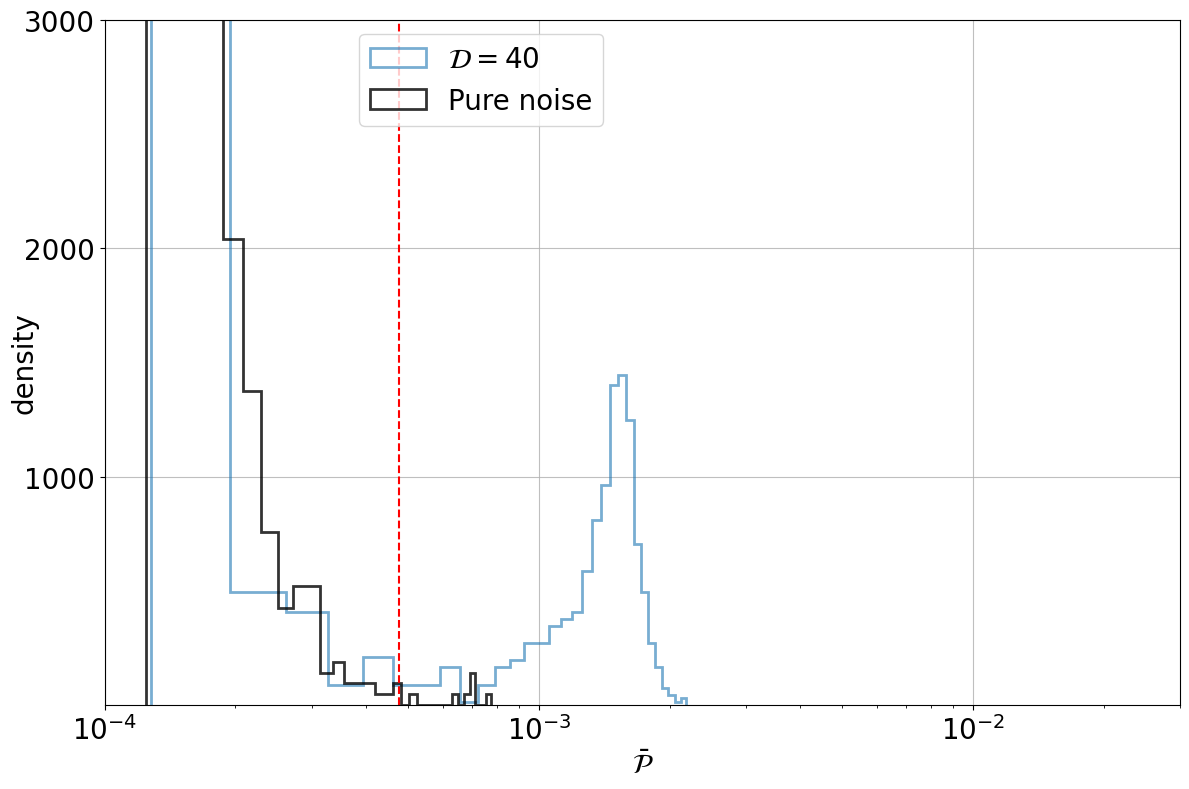

In [9]:
#x_pfa = np.zeros(4)
fig, axs = plt.subplots(1, 1, figsize=(12, 8))
    # Plot histograms
for label, x_values in results_dict.items():
    if label != np.inf:

        axs.hist(x_values, label=r'$\mathcal{D}=$'+str(int(label)), bins=int(np.sqrt(x_values.size)), alpha=0.6, histtype='step', linewidth=2, density=True)
    else:    
        axs.hist(x_values, label="Pure noise", alpha=0.8, histtype='step', bins=int(np.sqrt(x_values.size)), linewidth=2, color='k', density=True)
        x_pfa = np.percentile(x_values, (1-0.71/100)*100)
        #plt.hist(mask_dict, label="Mask", alpha=0.8, histtype='step', bins=int(np.sqrt(mask_dict.size)), linewidth=2, density=True, color='r')

axs.vlines(x=x_pfa, ymin=0, ymax=4000, color='r', ls='--')
# Add labels and legend
axs.set_xlabel(r'$\bar \mathcal{P}$', fontsize=20)
axs.set_ylabel('density', fontsize=20, labelpad=-10)
axs.legend(fontsize=20, loc='upper center', bbox_to_anchor=(0.35, 1))

axs.grid(alpha=0.8)
axs.set_ylim(0, 3000)
axs.set_xscale('log')
axs.set_xlim(1e-4, 3e-2)
#axs.set_xticks([i for i in [2e-4, 5e-4, 1e-3, 3e-3]])  # Ticks every 5 weeks
#axs.set_xticklabels([f'{i}' for i in [r'$2\times 10^{-4}$', r'$5\times 10^{-4}$', r'$1\times10^{-3}$', r'$2\times10^{-3}$']])

axs.set_yticks([i for i in [1000, 2000, 3000]])  # Ticks every 5 weeks
axs.set_yticklabels([f'{i}' for i in [1000, 2000, 3000]])

# We change the fontsize of minor ticks label 
axs.tick_params(axis='both', which='major', labelsize=20)
axs.tick_params(axis='both', which='minor', labelsize=20)

plt.tight_layout()
#plt.savefig('./plots/det_stat.pdf'.format(version))
#plt.savefig('./plots/pdet_train_pdet.png'.format(version))

#plt.yscale('log')

In [12]:
depth = []
pdet = []
mask_dict = {}
for key in results_dict.keys():
    #if key != np.inf:
    mask = np.zeros(results_dict[key].size, dtype=bool)
    data = results_dict[key]
        #print((data>x_pfa[j]).shape)
    mask = (data>x_pfa)
    mask_dict[key] = mask
    if key != np.inf:
        depth.append(key)
        pdet.append( mask.sum()/data.size )

depth = np.array(depth)
pdet = np.array(pdet)

In [13]:
depth, pdet

(array([40.2790268]), array([0.714]))

In [9]:
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy import stats
from PIL import Image
# Matplotlib configuration for consistent, readable plots
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 20
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import warnings

class fitSigmoid:    
    def __init__(self, nInj=100):
        self.nInj = nInj         # number of injections per point

    def sigmoid(self, x, k, x0):
        return 1./(1.+np.exp(-k*(x-x0))) 

    def inv_sigmoid(self, y, k, x0):
        return -np.log(1./y-1.) /k +x0        

    def transfromX(self, d):
        return d/self.dmax *2 - 1 
    
    def transfromD(self, x):
        return (x+1)/2*self.dmax 
    
    def binomialError(self, y, n):
        err =  np.sqrt(y*(1.-y)/n)
        err[err==0] = 1./n
        return err

    def d_fromPercentile(self, per=0.9):    
        x = self.inv_sigmoid(per, *self.popt)
        d = self.transfromD(x)
        a, b = self.popt.T
        dxda =  -1.0/a**2 * np.log(per/(1-per))
        dxdb = 1.0
        dx = np.sqrt(self.pcov[0,0]*dxda**2 + self.pcov[1,1]*dxdb**2 + 2*self.pcov[0,1]*dxda*dxdb)

        return d, dx

    def fit(self, d, p):        
        self.dmax = np.max(d)
        err = self.binomialError(p, self.nInj)
        x = self.transfromX(d)
        self.popt, self.pcov = curve_fit(self.sigmoid, x, p, p0=[0,100], sigma=err) 
        return 0
    
    def plot(self, cosi, d_list, p, savePath='./sigmoid.pdf'):
        fig, ax = plt.subplots(figsize=(10, 6))
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color'] 
        
        
        d_low, _ = self.d_fromPercentile(per=0.001)
        d_high, _ = self.d_fromPercentile(per=0.999)
        d_low, d_high = min(d_list[0], d_low), max(d_list[-1],d_high)
        d_arr = np.linspace(d_low, d_high, 100)
        x_arr = self.transfromX(d_arr)
        
        p_inter = self.sigmoid(x_arr, *self.popt)
        ax.plot(d_arr, p_inter, color=colors[0], label='fit')
                 
        ax.scatter(d_list, p, color='black')
        err = self.binomialError(p, self.nInj)
        ax.errorbar(d_list, p, yerr=err, fmt='', color='k', ls='none')
               
        d90, dx = self.d_fromPercentile(per=0.9)
        dx = dx /2 * self.dmax
        p90 = 0.9
        x_highlighting = [0, d90, d90]
        y_highlighting = [p90, p90, -1]

        if cosi is None:
            plt.plot(x_highlighting, y_highlighting, color='r', label=r'$\mathcal{D}^{90\%}=$'+'{:.1f}'.format(d90)+r'$\pm$'+'{:.1f}'.format(np.abs(dx)))
        else:
            plt.plot(x_highlighting, y_highlighting, color='r', label=r'$\mathcal{D}^{90\%}=$'+'{:.1f}'.format(d90)+r'$\pm$'+'{:.1f}'.format(np.abs(dx))+r'$\; (\cos \iota =$'+str(cosi)+')')

        ax.legend()
        ax.set_ylim(-0.05, 1.05)
        #ax.set_xlim(0.9*min(min(d_list), d_arr[0]), 1.05*min(max(d_list), max(d_arr)))       
        plt.xlabel(r'$\mathcal{D}\; (\mathrm{Hz}^{-1/2})$')
        ax.set_ylabel(r'$p_{\mathrm{det}}$')
        #plt.legend(loc=3)
        ax.set_xlim(0.9*min(min(d_list), d_arr[0]), 1.0*40)       
        plt.grid(alpha=1, which='major')
        plt.grid(alpha=0.3, which='minor')
        plt.minorticks_on() 
        #fig.savefig(savePath)
        return fig
    

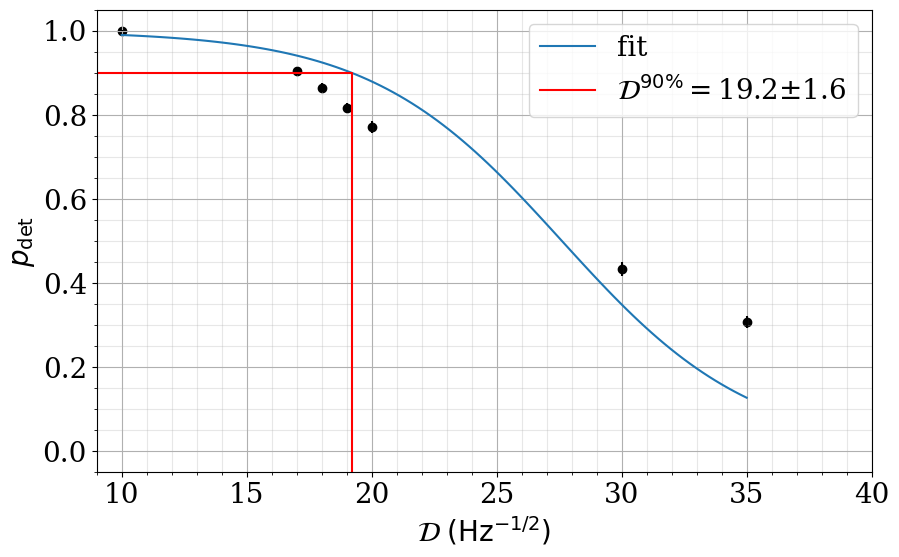

In [10]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color'] 
fit = fitSigmoid(1000)
fit.fit(depth[:-1], pdet[:-1])
fig = fit.plot(None, depth, pdet)
depth_joshi = 20.1
#plt.vlines(x=depth_joshi, ymin=-1,ymax=2, color=colors[2], label='{} (Joshi et al. 2024)'.format(depth_joshi))
depth_weave = 41.5
#plt.vlines(x=depth_weave, ymin=-1,ymax=2, color=colors[4], label='Weave')

plt.legend()
#plt.savefig('./plots/pdet_{}_3+1day_gaps.pdf'.format(version))
#plt.savefig('./plots/pdet.pdf'.format(version))
#plt.savefig('./plots/pdet_{}.png'.format(version))
plt.show()

Evaluating 1000Hz: 100%|██████████| 250/250 [00:12<00:00, 19.39it/s]


Plot saved as 'pdet_vs_frequency.png'


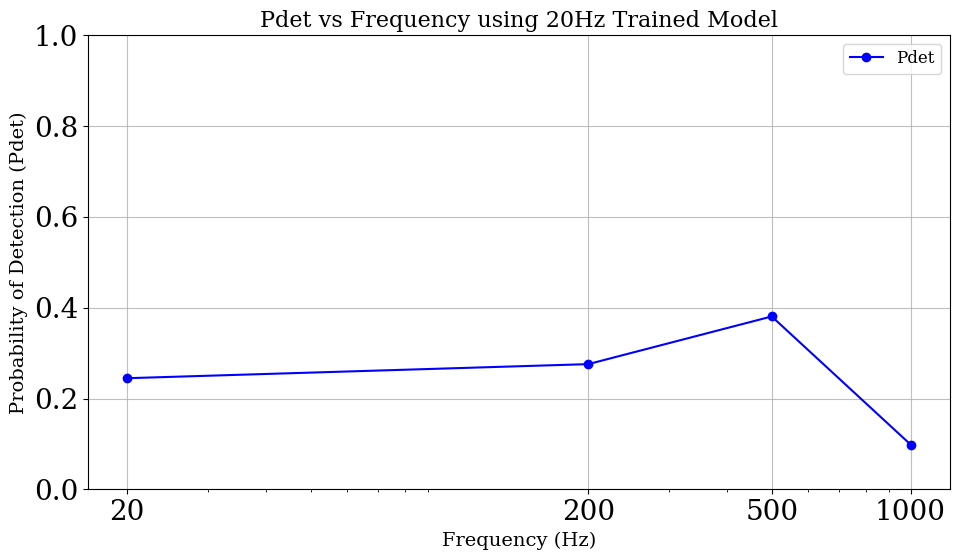

In [22]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from utils import *
from genData import *
from model.unet import Attention_UNet

# Set random seeds for reproducibility
np.random.seed(111)
torch.manual_seed(111)

# Constants
det = 'H1L1'
size = (512, 64)
Tsft = 14400
max_train_levels = [36.77]
frequencies = [20, 200, 500, 1000]
train_level = 22
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize model and load weights
model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
version = f'H1L1_a1b1_500Hz_D{train_level}-{train_level}_T10_f512xTsft14400_ndata7000_noise7000_latent64_batch8_lr0.0001_512x64_MSELoss_dropout0'
model.load_state_dict(torch.load(f"../trained_model/500Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False))
model.eval()

def compute_detection_statistic(images, method='mean'):
    valid_methods = {'mean', 'mean_sq'}
    if method not in valid_methods:
        raise ValueError(f"Method must be one of {valid_methods}, got {method}")
    images_np = np.abs(images)
    if method == 'mean':
        return np.mean(images_np.transpose(0, 2, 3, 1), axis=(1, 2, 3))
    elif method == 'mean_sq':
        return np.mean(np.square(images_np.transpose(0, 2, 3, 1)), axis=(1, 2, 3))

# Compute pdet for each frequency
pdet_values = []
for f0 in frequencies:
    # Load validation data
    filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{f0}Hz_H1L1_{size[0]}x{size[1]}_{Tsft}s_4c_traindata_n1000_seed4.npz'
    targets = np.load(filename, allow_pickle=True)['clean_image']
    masks = new_mask(normalize(targets))

    # Generate signal data
    data = []
    mask_data = []
    target_data = []
    label_data = []
    for Sn in max_train_levels:
        noise = np.empty((targets.shape[0],) + size + (4,))
        for i in range(noise.shape[0]):
            noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)
        data.append(normalize(noise + targets))
        mask_data.append(masks)
        target_data.append(normalize(targets))
        labels = [Sn] * noise.shape[0]
        label_data.append(labels)

    data = np.concatenate(data)
    mask_data = np.concatenate(mask_data)
    target_data = np.concatenate(target_data)
    label_data = np.concatenate(label_data)
    data = load_signal_datasetv2(data, target_data, mask_data, label_data)

    # Generate noise data
    noise = np.empty((1000,) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=1, Tsft=Tsft, size=size, ndet=2, norm=False)
    noise = normalize(noise)
    noise_data = load_noise_dataset(noise)

    # Create data loader
    val_loader = make_data_loader([data, noise_data], batch_size=8, shuffle=False)

    # Run inference
    inputs = []
    predictions = []
    ground_truth = []
    masks = []
    labels = []
    with torch.no_grad():
        for test_batch in tqdm(val_loader, desc=f'Evaluating {f0}Hz'):
            test_images, test_targets, test_masks, test_labels = test_batch
            test_images = test_images.to(device)
            test_targets = test_targets.to(device)
            test_masks = test_masks.to(device)
            test_labels = test_labels.to(device)
            outputs = model(test_images)
            inputs.append(test_images.cpu().numpy())
            predictions.append(outputs.cpu().numpy())
            ground_truth.append(test_targets.cpu().numpy())
            masks.append(test_masks.cpu().numpy())
            labels.append(test_labels.cpu().numpy())

    inputs = np.concatenate(inputs, axis=0)
    predictions = np.concatenate(predictions, axis=0)
    ground_truth = np.concatenate(ground_truth, axis=0)
    masks = np.concatenate(masks, axis=0)
    labels = np.concatenate(labels, axis=0)

    # Compute detection statistics
    results_dict = {}
    unique_labels = np.unique(labels)
    for label in unique_labels:
        indices = np.where(labels == label)[0]
        results_dict[label] = compute_detection_statistic(predictions[indices], method='mean')

    # Compute x_pfa from noise (label=np.inf)
    x_pfa = np.percentile(results_dict[np.inf], (1-0.71/100)*100) if np.inf in results_dict else np.percentile(results_dict[max_train_levels[0]], (1-0.71/100)*100)

    # Compute pdet
    mask_dict = {}
    for key in results_dict.keys():
        data = results_dict[key]
        mask = data > x_pfa
        mask_dict[key] = mask
        if key != np.inf:
            pdet = mask.sum() / data.size
            pdet_values.append(pdet)

# Plot pdet vs frequency
plt.figure(figsize=(10, 6))
plt.plot(frequencies, pdet_values, marker='o', linestyle='-', color='b', label='Pdet')
plt.xlabel('Frequency (Hz)', fontsize=14)
plt.ylabel('Probability of Detection (Pdet)', fontsize=14)
plt.title('Pdet vs Frequency using 20Hz Trained Model', fontsize=16)
plt.grid(True, alpha=0.8)
plt.xscale('log')
plt.xticks(frequencies, [str(f) for f in frequencies])
plt.ylim(0, 1)
plt.legend(fontsize=12)
plt.tight_layout()
#plt.savefig('pdet_vs_frequency.png')
#plt.close()

print("Plot saved as 'pdet_vs_frequency.png'")

Plot saved as 'pdet_vs_frequency.png'


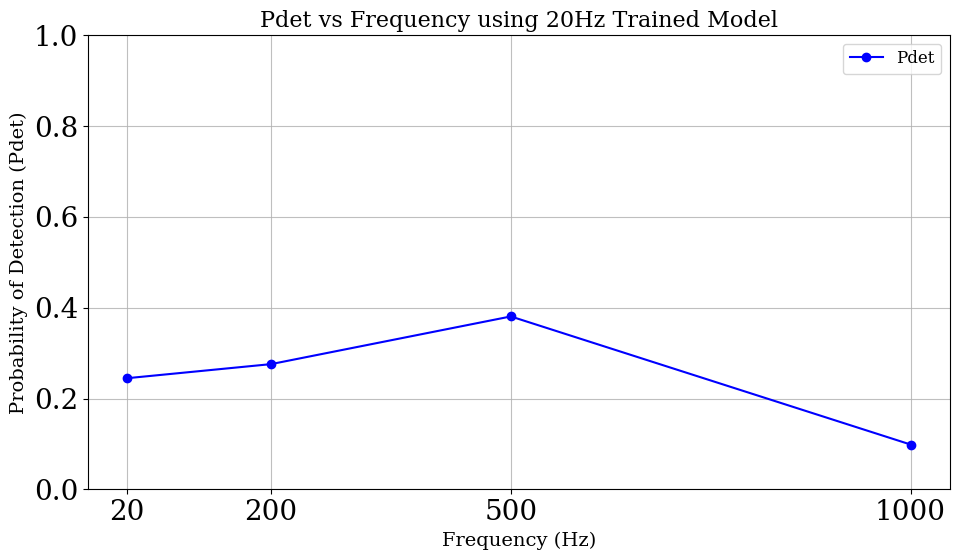

In [23]:
# Plot pdet vs frequency
plt.figure(figsize=(10, 6))
plt.plot(frequencies, pdet_values, marker='o', linestyle='-', color='b', label='Pdet')
plt.xlabel('Frequency (Hz)', fontsize=14)
plt.ylabel('Probability of Detection (Pdet)', fontsize=14)
plt.title('Pdet vs Frequency using 20Hz Trained Model', fontsize=16)
plt.grid(True, alpha=0.8)
#plt.xscale('log')
plt.xticks(frequencies, [str(f) for f in frequencies])
plt.ylim(0, 1)
plt.legend(fontsize=12)
plt.tight_layout()
#plt.savefig('pdet_vs_frequency.png')
#plt.close()

print("Plot saved as 'pdet_vs_frequency.png'")

In [24]:
frequencies, pdet_values


([20, 200, 500, 1000], [0.245, 0.276, 0.381, 0.099])

Evaluating 1000Hz: 100%|██████████| 250/250 [00:13<00:00, 18.84it/s]


Plot saved as 'pdet_vs_frequency.png'


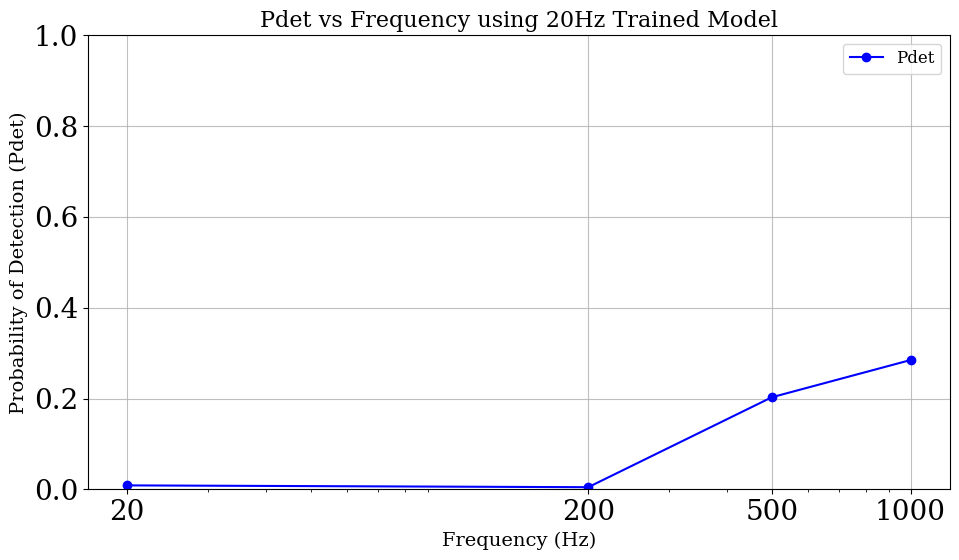

In [26]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from utils import *
from genData import *
from model.unet import Attention_UNet

# Set random seeds for reproducibility
np.random.seed(111)
torch.manual_seed(111)

# Constants
det = 'H1L1'
size = (512, 64)
Tsft = 14400
max_train_levels = [34.50]
frequencies = [20, 200, 500, 1000, 0]
train_level = 19
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize model and load weights
model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
version = f'H1L1_a1.0b1.0_1000Hz_D{train_level}-{train_level}_T10_Tsft14400_ndata7000_noise7000_latent64_batch8_lr0.0001_512x64_MSELoss_dropout0'
model.load_state_dict(torch.load(f"../trained_model/1000Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False))
model.eval()

def compute_detection_statistic(images, method='mean'):
    valid_methods = {'mean', 'mean_sq'}
    if method not in valid_methods:
        raise ValueError(f"Method must be one of {valid_methods}, got {method}")
    images_np = np.abs(images)
    if method == 'mean':
        return np.mean(images_np.transpose(0, 2, 3, 1), axis=(1, 2, 3))
    elif method == 'mean_sq':
        return np.mean(np.square(images_np.transpose(0, 2, 3, 1)), axis=(1, 2, 3))

# Compute pdet for each frequency
pdet_values = []
for f0 in frequencies:
    # Load validation data
    filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{f0}Hz_H1L1_{size[0]}x{size[1]}_{Tsft}s_4c_traindata_n1000_seed4.npz'
    targets = np.load(filename, allow_pickle=True)['clean_image']
    masks = new_mask(normalize(targets))

    # Generate signal data
    data = []
    mask_data = []
    target_data = []
    label_data = []
    for Sn in max_train_levels:
        noise = np.empty((targets.shape[0],) + size + (4,))
        for i in range(noise.shape[0]):
            noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)
        data.append(normalize(noise + targets))
        mask_data.append(masks)
        target_data.append(normalize(targets))
        labels = [Sn] * noise.shape[0]
        label_data.append(labels)

    data = np.concatenate(data)
    mask_data = np.concatenate(mask_data)
    target_data = np.concatenate(target_data)
    label_data = np.concatenate(label_data)
    data = load_signal_datasetv2(data, target_data, mask_data, label_data)

    # Generate noise data
    noise = np.empty((1000,) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=1, Tsft=Tsft, size=size, ndet=2, norm=False)
    noise = normalize(noise)
    noise_data = load_noise_dataset(noise)

    # Create data loader
    val_loader = make_data_loader([data, noise_data], batch_size=8, shuffle=False)

    # Run inference
    inputs = []
    predictions = []
    ground_truth = []
    masks = []
    labels = []
    with torch.no_grad():
        for test_batch in tqdm(val_loader, desc=f'Evaluating {f0}Hz'):
            test_images, test_targets, test_masks, test_labels = test_batch
            test_images = test_images.to(device)
            test_targets = test_targets.to(device)
            test_masks = test_masks.to(device)
            test_labels = test_labels.to(device)
            outputs = model(test_images)
            inputs.append(test_images.cpu().numpy())
            predictions.append(outputs.cpu().numpy())
            ground_truth.append(test_targets.cpu().numpy())
            masks.append(test_masks.cpu().numpy())
            labels.append(test_labels.cpu().numpy())

    inputs = np.concatenate(inputs, axis=0)
    predictions = np.concatenate(predictions, axis=0)
    ground_truth = np.concatenate(ground_truth, axis=0)
    masks = np.concatenate(masks, axis=0)
    labels = np.concatenate(labels, axis=0)

    # Compute detection statistics
    results_dict = {}
    unique_labels = np.unique(labels)
    for label in unique_labels:
        indices = np.where(labels == label)[0]
        results_dict[label] = compute_detection_statistic(predictions[indices], method='mean')

    # Compute x_pfa from noise (label=np.inf)
    x_pfa = np.percentile(results_dict[np.inf], (1-0.71/100)*100) if np.inf in results_dict else np.percentile(results_dict[max_train_levels[0]], (1-0.71/100)*100)

    # Compute pdet
    mask_dict = {}
    for key in results_dict.keys():
        data = results_dict[key]
        mask = data > x_pfa
        mask_dict[key] = mask
        if key != np.inf:
            pdet = mask.sum() / data.size
            pdet_values.append(pdet)

# Plot pdet vs frequency
plt.figure(figsize=(10, 6))
plt.plot(frequencies, pdet_values, marker='o', linestyle='-', color='b', label='Pdet')
plt.xlabel('Frequency (Hz)', fontsize=14)
plt.ylabel('Probability of Detection (Pdet)', fontsize=14)
plt.title('Pdet vs Frequency using 20Hz Trained Model', fontsize=16)
plt.grid(True, alpha=0.8)
plt.xscale('log')
plt.xticks(frequencies, [str(f) for f in frequencies])
plt.ylim(0, 1)
plt.legend(fontsize=12)
plt.tight_layout()
#plt.savefig('pdet_vs_frequency.png')
#plt.close()

print("Plot saved as 'pdet_vs_frequency.png'")

Plot saved as 'pdet_vs_frequency.png'


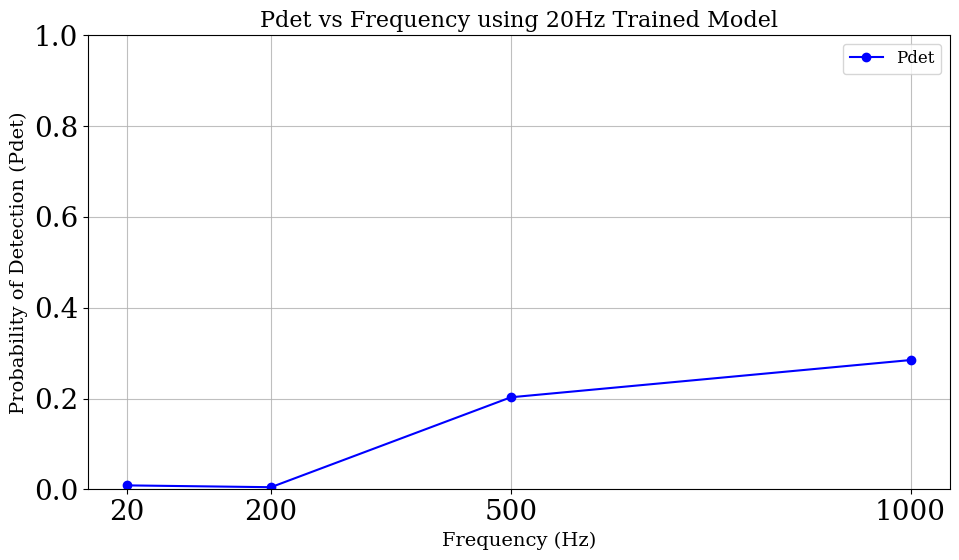

In [27]:
# Plot pdet vs frequency
plt.figure(figsize=(10, 6))
plt.plot(frequencies, pdet_values, marker='o', linestyle='-', color='b', label='Pdet')
plt.xlabel('Frequency (Hz)', fontsize=14)
plt.ylabel('Probability of Detection (Pdet)', fontsize=14)
plt.title('Pdet vs Frequency using 20Hz Trained Model', fontsize=16)
plt.grid(True, alpha=0.8)
#plt.xscale('log')
plt.xticks(frequencies, [str(f) for f in frequencies])
plt.ylim(0, 1)
plt.legend(fontsize=12)
plt.tight_layout()
#plt.savefig('pdet_vs_frequency.png')
#plt.close()

print("Plot saved as 'pdet_vs_frequency.png'")

In [28]:
frequencies, pdet_values


([20, 200, 500, 1000], [0.009, 0.005, 0.203, 0.285])